成功读取 superficial 数据，共 50 个数据点
成功读取 middle 数据，共 50 个数据点
成功读取 deep 数据，共 50 个数据点


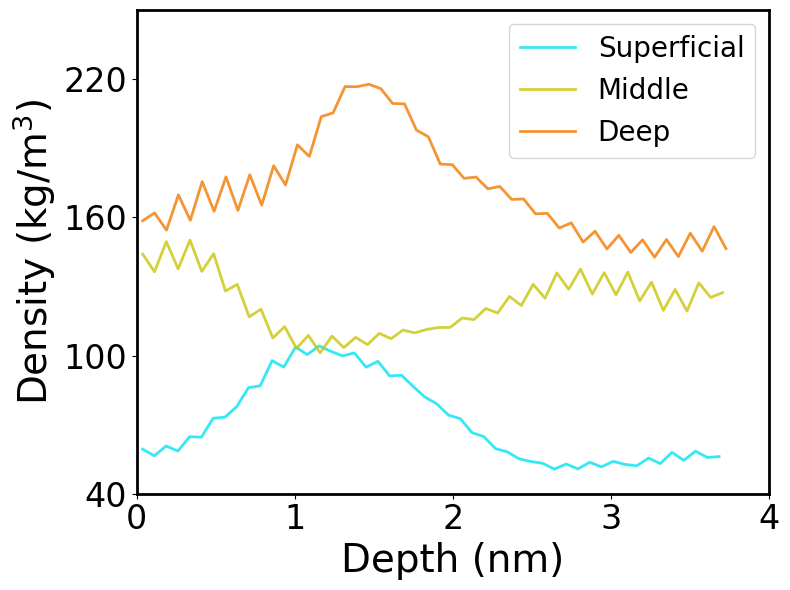

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

# 设置中文字体支持（如果需要）
# matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 定义三种模式
modes = ['superficial', 'middle', 'deep']
# 定义对应的颜色和标签
colors = {
    'superficial': "#03E2F2",
    'middle': "#C9C509",
    'deep': "#F37A00"
}
labels = {
    'superficial': 'Superficial',
    'middle': 'Middle',
    'deep': 'Deep'
}

def read_density_data(file_path):
    depth = []
    density = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # 跳过注释行（以#或@开头的行）
            if line.startswith('#') or line.startswith('@'):
                continue
            data = line.strip().split()
            if len(data) >= 2:  # 确保至少有2列数据
                depth.append(float(data[0]))   # 第一列是深度(nm)
                density.append(float(data[1]))  # 第二列是密度(kg/m^3)
    
    return np.array(depth), np.array(density)

fig, ax = plt.subplots(figsize=(8, 6))

for mode in modes:
    file_path = f'd-density_{mode}.xvg'
    
    try:
        depth, density = read_density_data(file_path)
    
        ax.plot(depth, density, 
                color=colors[mode], 
                linestyle='-', 
                linewidth=2, 
                label=labels[mode],
                alpha=0.8)
        
        print(f"成功读取 {mode} 数据，共 {len(density)} 个数据点")
        
    except FileNotFoundError:
        print(f"警告：文件 {file_path} 未找到，跳过")
    except Exception as e:
        print(f"读取 {file_path} 时出错：{e}")

ax.set_xlabel('Depth (nm)', fontsize=28)
ax.set_ylabel(r'Density (kg/m$^3$)', fontsize=28)
ax.set_xlim(0,4)
ax.set_ylim(40,250)
ax.set_xticks([0,1,2,3,4])
ax.set_yticks([40,100,160,220])
ax.tick_params(axis='both', which='major', labelsize=24)

ax.legend(fontsize=20, loc='upper right')
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()

output_file = 'density_comparison.tiff'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()